# Edge Detection

Gradients are regions in an image where pixel intensity changes. While gradients and edges are not exactly the same from a mathematical perspective, they are closely related in computer vision.

If thresholding is about separating the inside of an object from the outside, edge detection is about finding the exact boundaries where those changes occur.

An edge detection algorithm acts like a sensor that scans across an image, looking for sudden changes in brightness. These abrupt changes often indicate the boundary of an object.

There are many techniques for detecting edges, but one of the most widely used and effective methods in computer vision is the **Canny Edge Detector**.

**Laplacian**

Imagine running your finger across a table.

- Smooth surface → nothing interesting (no edge).
- Sudden drop at the table's boundary → edge.

The Canny detector is basically a robot finger that moves across the image looking for those sudden drops in brightness.

1. `cv.Laplacian()`
- Same brightness  -> No edge
- Sudden change    -> Edge
So it transforms the image into an "edge image".
<br>

2. `cv.CV_64F`
- store the result as 64-bit floating point numbers,，because Laplacian calcualtion can produce negative values. 

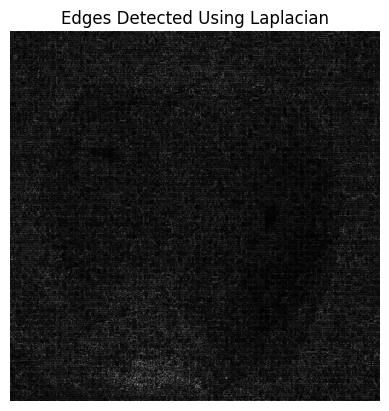

In [7]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img=cv.imread("../image/apple.jpg")
gray=cv.cvtColor(img,cv.COLOR_BGR2GRAY)

lap = cv.Laplacian(gray, cv.CV_64F)
lap=np.uint8(np.absolute(lap))

plt.imshow(lap,cmap="gray")
plt.title("Edges Detected Using Laplacian")
plt.axis("off")
plt.show()

**sobel**

```PYthon
cv.Sobel(image, depth, dx, dy)
```
- $dx$ = how much we care about change in x direction
- $dy$ = how much we care about change in y direction

- (1,0) → look in X direction (left → right) → measure horizontal change → detects vertical edges
- (0,1) → look in Y direction (top → bottom) → measure vertical change → detects horizontal edges



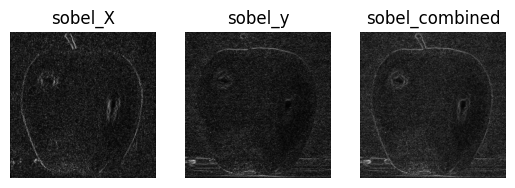

In [ ]:
# sobel 
sobelx=cv.Sobel(gray,cv.CV_64F,1,0)
sobely=cv.Sobel(gray,cv.CV_64F,0,1)

sobelx = np.uint8(np.absolute(sobelx))
sobely = np.uint8(np.absolute(sobely))  # must convert Sobel outputs to uint8 (after absolute) before using bitwise operations or plotting.
plt.subplot(1,3,1)
plt.title("sobel_X")
plt.imshow(sobelx,cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("sobel_y")
plt.imshow(sobely,cmap="gray") # cmap="gray" tells image is grayscale and it shows balck -> white only. 
plt.axis("off")


combined=cv.bitwise_or(sobelx,sobely)
plt.subplot(1,3,3)
plt.title("sobel_combined")
plt.imshow(combined,cmap="gray")  
plt.axis("off")

plt.show()

**Canny edge detector**
```PYTHON
cv.Canny(image, threshold1, threshold2)
```
- `image` : image must be in graysclae because color is not needed for edge detection
- `150 ` lower threshold  (weak edge limit), anything below this is not considered as edge.
- `175` upper threshold (strong edge limit), anything above this is definetely an edge. 

```TEXT
hysteresis thresholds (150,175)
150 = minimum edge strength
175 = strong edge confirmation
Canny keeps real edges and removes noise using both.


There is no fixed threshold.
Start with 100–200 and adjust based on:
- too many edges → increase
- too few edges → decrease

Low thresholds → sensitive (detects everything)
High thresholds → strict (detects only strong edges)

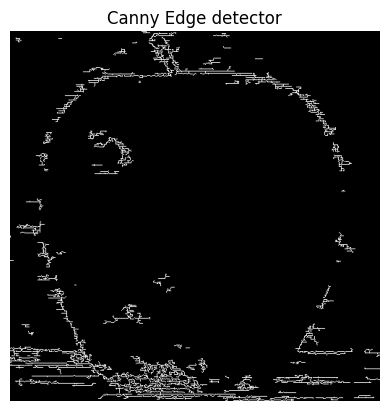

In [39]:
gray=cv.cvtColor(img,cv.COLOR_BGR2GRAY)
canny=cv.Canny(gray,50,145) #adjusted to see different possibilities

plt.imshow(canny,cmap="gray")
plt.title("Canny Edge detector")
plt.axis("off")
plt.show()

**Difference Between Laplacian, Sobel, and Canny Edge Detection**


##  Quick Comparison Table

| Feature | Sobel | Laplacian | Canny |
|----------|-------|------------|--------|
| Derivative type | First-order | Second-order | Multi-stage gradient |
| Direction | X & Y separately | All directions | All directions |
| Noise sensitivity | Medium | High | Low |
| Edge thickness | Thick | Very thick | Thin |
| Accuracy | Basic | Moderate | High |
| Complexity | Low | Low | High |


##  Simple intuition

- **Sobel** → “Where is brightness changing left/right or up/down?”
- **Laplacian** → “Where is brightness changing suddenly in any direction?”
- **Canny** → “Find real object edges, ignore noise, give clean results”


##  One-line summary

- Sobel = directional edge detection  
- Laplacian = overall edge strength detection  
- Canny = best clean edge detection pipeline

In mathematics
- Gradient = measurement of change
- Edge = a point/region where that measurement is unusually large

In math, a gradient measures the rate of change. In computer vision, an edge is usually a location where the gradient magnitude becomes very large.